# **Experiment_6A**

Using the Iris dataset, classify a new flower by applying the K-Nearest Neighbors (KNN) algorithm. The new flower has a Sepal Length of 6.0 and a Sepal Width of 3.0. First, compute the Euclidean distance between the new data point and all existing data points in the dataset. Then, identify the three nearest neighbors by applying KNN with K = 3. Based on the majority class of the nearest neighbors, determine the predicted class of the new flower. Finally, show the complete calculation process and explain the final classification using a visualization plot.

**Using the Iris dataset, classify a new flower with Sepal Length = 6.0 and Sepal Width = 3.0 using the KNN algorithm. Compute the Euclidean distance from the new point to all existing data points, identify the three nearest neighbors (K = 3), and determine the final predicted class based on majority voting. Show the necessary calculations and explain the final result using a visualization plot.**

| Sepal Length | Sepal Width | Species    |
| ------------ | ----------- | ---------- |
| 5.3          | 3.7         | Setosa     |
| 5.1          | 3.8         | Setosa     |
| 7.2          | 3.0         | Virginica  |
| 5.4          | 3.4         | Setosa     |
| 5.1          | 3.3         | Setosa     |
| 5.4          | 3.9         | Setosa     |
| 7.4          | 2.8         | Virginica  |
| 6.1          | 2.8         | Versicolor |
| 7.3          | 2.9         | Virginica  |
| 6.0          | 2.7         | Versicolor |
| 5.8          | 2.8         | Virginica  |
| 6.3          | 2.3         | Versicolor |
| 5.1          | 2.5         | Versicolor |
| 6.3          | 2.5         | Versicolor |
| 5.5          | 2.4         | Versicolor |

A new flower has:

Sepal Length = 6.0

Sepal Width = 3.0

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
# Given Iris (SepalLength, SepalWidth, Species)

data = [
    (5.3, 3.7, "Setosa"),
    (5.1, 3.8, "Setosa"),
    (7.2, 3.0, "Virginica"),
    (5.4, 3.4, "Setosa"),
    (5.1, 3.3, "Setosa"),
    (5.4, 3.9, "Setosa"),
    (7.4, 2.8, "Virginica"),
    (6.1, 2.8, "Versicolor"),
    (7.3, 2.9, "Virginica"),
    (6.0, 2.7, "Versicolor"),
    (5.8, 2.8, "Virginica"),
    (6.3, 2.3, "Versicolor"),
    (5.1, 2.5, "Versicolor"),
    (6.3, 2.5, "Versicolor"),
    (5.5, 2.4, "Versicolor"),
]

df = pd.DataFrame(data, columns=["SepalLength", "SepalWidth", "Species"])

In [ ]:
df

,SepalLength,SepalWidth,Species
0,5.3,3.7,Setosa
1,5.1,3.8,Setosa
2,7.2,3.0,Virginica
3,5.4,3.4,Setosa
4,5.1,3.3,Setosa
5,5.4,3.9,Setosa
6,7.4,2.8,Virginica
7,6.1,2.8,Versicolor
8,7.3,2.9,Virginica
9,6.0,2.7,Versicolor


In [ ]:
# New point
new_point = np.array([6.0, 3.0])
k = 3

In [ ]:
# Compute Euclidean distances
X = df[["SepalLength", "SepalWidth"]].to_numpy()
distances = np.sqrt(np.sum((X - new_point) ** 2, axis=1))
df["Distance"] = distances

# Sort by distance
df_sorted = df.sort_values("Distance").reset_index(drop=True)

print("All distances (sorted):")
print(df_sorted[["SepalLength", "SepalWidth", "Species", "Distance"]])

All distances (sorted):
    SepalLength  SepalWidth     Species  Distance
0           6.1         2.8  Versicolor  0.223607
1           5.8         2.8   Virginica  0.282843
2           6.0         2.7  Versicolor  0.300000
3           6.3         2.5  Versicolor  0.583095
4           5.4         3.4      Setosa  0.721110
5           6.3         2.3  Versicolor  0.761577
6           5.5         2.4  Versicolor  0.781025
7           5.1         3.3      Setosa  0.948683
8           5.3         3.7      Setosa  0.989949
9           5.1         2.5  Versicolor  1.029563
10          5.4         3.9      Setosa  1.081665
11          7.2         3.0   Virginica  1.200000
12          5.1         3.8      Setosa  1.204159
13          7.3         2.9   Virginica  1.303840
14          7.4         2.8   Virginica  1.414214


In [ ]:
# Take K nearest neighbors
neighbors = df_sorted.head(k)
print("\nK Nearest Neighbors (K=3):")
print(neighbors[["SepalLength", "SepalWidth", "Species", "Distance"]])


K Nearest Neighbors (K=3):
   SepalLength  SepalWidth     Species  Distance
0          6.1         2.8  Versicolor  0.223607
1          5.8         2.8   Virginica  0.282843
2          6.0         2.7  Versicolor  0.300000


In [ ]:
# Majority vote
vote = Counter(neighbors["Species"])
predicted_class = vote.most_common(1)[0][0]
print("\nPredicted Class =", predicted_class)


Predicted Class = Versicolor


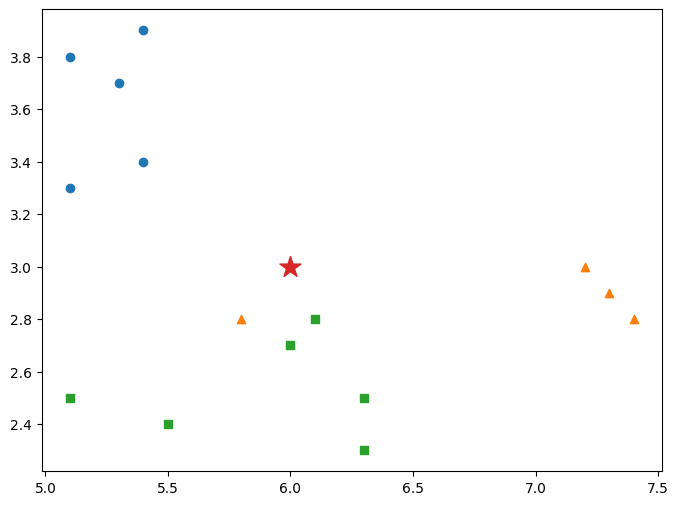

In [ ]:
# Visualization plot
species_list = df["Species"].unique()
markers = {"Setosa": "o", "Versicolor": "s", "Virginica": "^"}

plt.figure(figsize=(8, 6))

# Plot training points by class
for sp in species_list:
    sub = df[df["Species"] == sp]
    plt.scatter(sub["SepalLength"], sub["SepalWidth"], marker=markers.get(sp, "o"), label=sp)

# Plot new point
plt.scatter(new_point[0], new_point[1], marker="*", s=250, label="New Point (6.0, 3.0)")

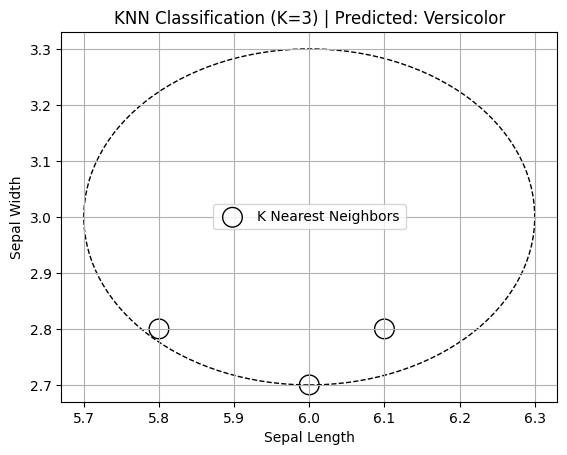

In [ ]:
# Highlight neighbors
plt.scatter(neighbors["SepalLength"], neighbors["SepalWidth"], facecolors="none", edgecolors="black", s=200, label="K Nearest Neighbors")

# draw circle with radius = distance to kth neighbor
radius = neighbors["Distance"].iloc[-1]
circle = plt.Circle((new_point[0], new_point[1]), radius, fill=False, linestyle="--")
plt.gca().add_patch(circle)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title(f"KNN Classification (K={k}) | Predicted: {predicted_class}")
plt.legend()
plt.grid(True)
plt.show()